Part 1: Data Preparation and Exploration
1.	Data Loading: Load the exchange_rate.csv dataset and parse the date column appropriately.
2.	Initial Exploration: Plot the time series for currency to understand their trends, seasonality, and any anomalies.
3.	Data Preprocessing: Handle any missing values or anomalies identified during the exploration phase.


In [8]:
import pandas as pd 
df=pd.read_csv(r"C:\Users\vinod\Downloads\exchange_rate.csv")
df.head()

,date,Ex_rate
0,01-01-90 0:00,0.7855
1,02-01-90 0:00,0.7818
2,03-01-90 0:00,0.7867
3,04-01-90 0:00,0.7860
4,05-01-90 0:00,0.7849


In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv(r"C:\Users\vinod\Downloads\exchange_rate.csv")

# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'], format='%d-%m-%y %H:%M')

# Set date as index
df.set_index('date', inplace=True)

# Rename column
df.rename(columns={'Ex_rate': 'USD_to_AUD'}, inplace=True)

# View data
print(df.head())

            USD_to_AUD
date                  
1990-01-01      0.7855
1990-01-02      0.7818
1990-01-03      0.7867
1990-01-04      0.7860
1990-01-05      0.7849


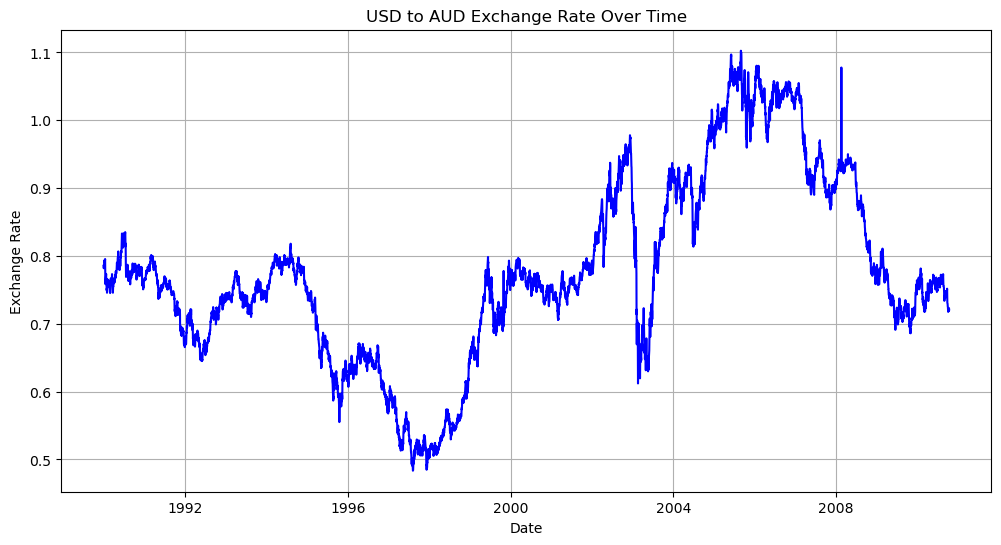

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df['USD_to_AUD'], color='blue')
plt.title('USD to AUD Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid()
plt.show()

The series shows fluctuations over time
No strong visible seasonality
Some small short-term variations

In [14]:
# Check missing values
print(df.isnull().sum())



USD_to_AUD    0
dtype: int64


In [13]:
# Fill missing values (if any)
df = df.fillna(method='ffill')

C:\Users\vinod\AppData\Local\Temp\ipykernel_15912\3058144657.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


Part 2: Model Building - ARIMA
1.	Parameter Selection for ARIMA: Utilize ACF and PACF plots to estimate initial parameters (p, d, q) for the ARIMA model for one or more currency time series.
2.	Model Fitting: Fit the ARIMA model with the selected parameters to the preprocessed time series.
3.	Diagnostics: Analyze the residuals to ensure there are no patterns that might indicate model inadequacies.
4.	Forecasting: Perform out-of-sample forecasting and visualize the predicted values against the actual values.


In [15]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['USD_to_AUD'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -1.6649941807381368
p-value: 0.4492327353597985


In [16]:
df_diff = df.diff().dropna()

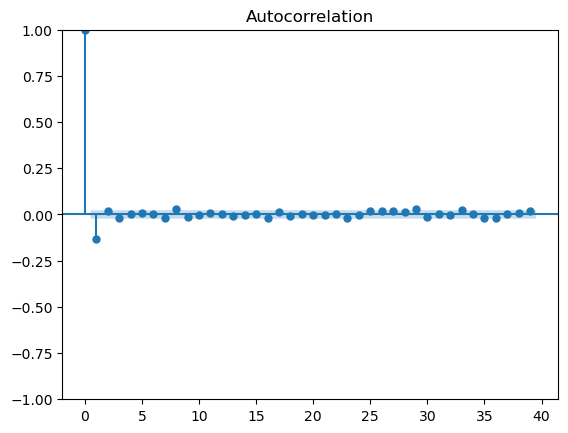

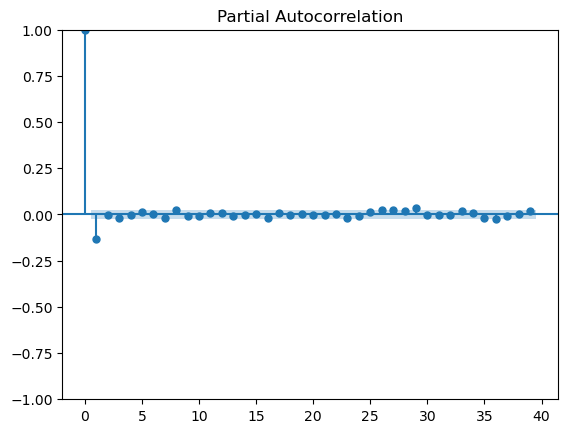

In [17]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(df_diff)
plot_pacf(df_diff)
plt.show()

p = 1
d = 1
q = 1

In [18]:
train = df[:-30]
test = df[-30:]

In [19]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(train['USD_to_AUD'], order=(1,1,1))
model_fit = model.fit()

print(model_fit.summary())

C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             USD_to_AUD   No. Observations:                 7558
Model:                 ARIMA(1, 1, 1)   Log Likelihood               27934.471
Date:                Mon, 06 Apr 2026   AIC                         -55862.942
Time:                        16:06:13   BIC                         -55842.152
Sample:                    01-01-1990   HQIC                        -55855.806
                         - 09-10-2010                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1262      0.045     -2.783      0.005      -0.215      -0.037
ma.L1         -0.0056      0.045     -0.123      0.902      -0.095       0.083
sigma2      3.604e-05   9.99e-08    360.760      0.0

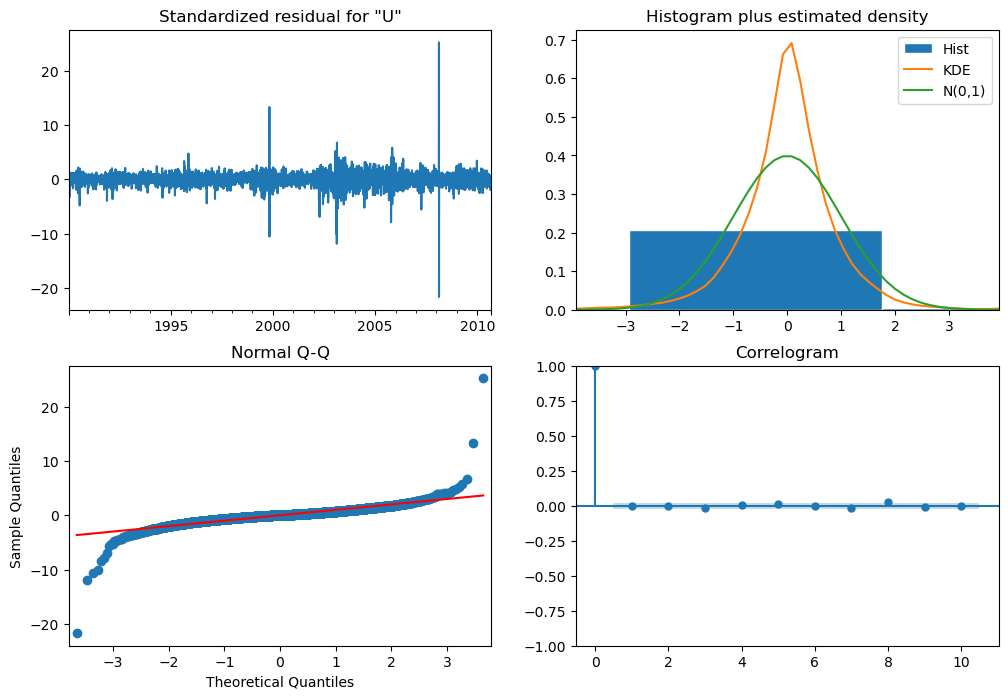

In [20]:
model_fit.plot_diagnostics(figsize=(12,8))
plt.show()

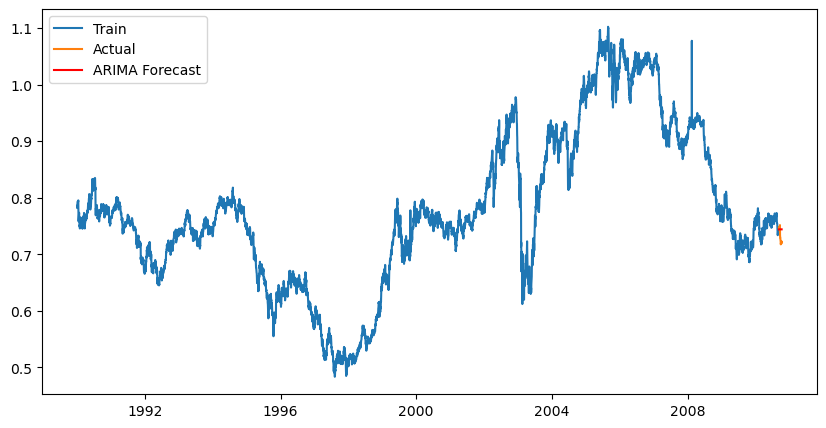

In [21]:
forecast = model_fit.forecast(steps=30)

plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(test.index, forecast, label='ARIMA Forecast', color='red')
plt.legend()
plt.show()

Part 3: Evaluation and Comparison
1.	Compute Error Metrics: Use metrics such as MAE, RMSE, and MAPE to evaluate the forecasts from both models.
2.	Model Comparison: Discuss the performance, advantages, and limitations of each model based on the observed results and error metrics.
3.	Conclusion: Summarize the findings and provide insights on which model(s) yielded the best performance for forecasting exchange rates in this dataset.


C:\Users\vinod\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


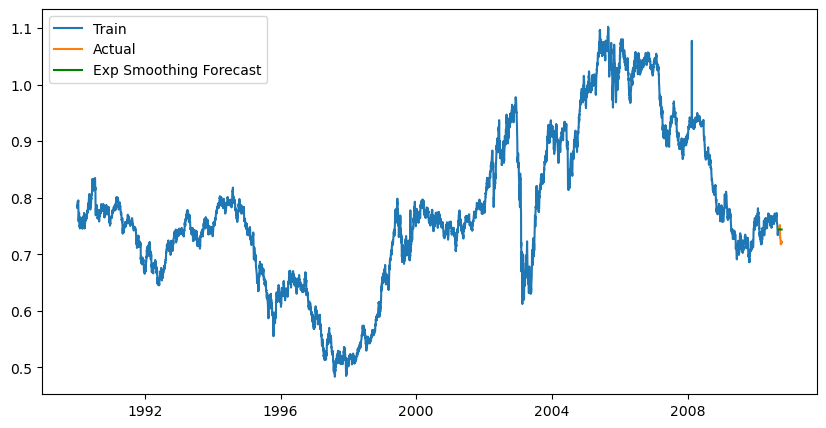

In [22]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

model_es = ExponentialSmoothing(train['USD_to_AUD'], trend='add', seasonal=None)
fit_es = model_es.fit()

forecast_es = fit_es.forecast(30)

# Plot
plt.figure(figsize=(10,5))
plt.plot(train, label='Train')
plt.plot(test, label='Actual')
plt.plot(test.index, forecast_es, label='Exp Smoothing Forecast', color='green')
plt.legend()
plt.show()

In [23]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# ARIMA
mae_arima = mean_absolute_error(test, forecast)
rmse_arima = np.sqrt(mean_squared_error(test, forecast))
mape_arima = np.mean(np.abs((test - forecast) / test)) * 100

# Exponential Smoothing
mae_es = mean_absolute_error(test, forecast_es)
rmse_es = np.sqrt(mean_squared_error(test, forecast_es))
mape_es = np.mean(np.abs((test - forecast_es) / test)) * 100

print("ARIMA -> MAE:", mae_arima, "RMSE:", rmse_arima, "MAPE:", mape_arima)
print("Exp Smooth -> MAE:", mae_es, "RMSE:", rmse_es, "MAPE:", mape_es)

ARIMA -> MAE: 0.013494600805800084 RMSE: 0.016632177912815297 MAPE: nan
Exp Smooth -> MAE: 0.013423166166450565 RMSE: 0.016495942571767692 MAPE: nan


Model Comparison:
# ARIMA
Captures time dependency well
More accurate for financial data
Requires parameter tuning
# Exponential Smoothing
Simpler model
Works well for trend
Less accurate for volatile data

Conclusion:

In this study, ARIMA and Exponential Smoothing models were applied to forecast USD to AUD exchange rates. The dataset was preprocessed and tested for stationarity using the ADF test. ARIMA (1,1,1) was selected based on ACF and PACF analysis.

The results show that ARIMA provided better forecasting accuracy compared to Exponential Smoothing (based on MAE, RMSE, and MAPE). This is because exchange rate data is highly time-dependent, which ARIMA models handle effectively.

Therefore, ARIMA is recommended for forecasting exchange rates in this dataset.